# 03 · Feature engineering

**Fase CRISP-DM:** preparación de los datos (construcción de variables y partición).

**Objetivo.** Agregar a la tabla por zona las variables del modelado, fijar los predictores y reservar el conjunto de
prueba por bloques espaciales **antes** de cualquier modelo.

| | |
|---|---|
| **Entradas** | `data/interim/zonas.parquet`, `kontur_h3r8.parquet`, `consultas_limpias.parquet`, `data/raw/gtfs/` |
| **Salidas** | `data/processed/tabla_modelado.parquet` y `resultados/03_feature_engineering/test_blocks.csv` (bloques de prueba) |
| **Resultados** | `resultados/03_feature_engineering/` (particiones, correlaciones, figuras y `metricas.json`) |

Variables que se construyen:

| Grupo | Variables | Uso |
|---|---|---|
| Objetivo | `query_count` | y (conteo del período) |
| Exposición | `population` | offset `log(population)`: convierte el conteo en tasa por habitante |
| Predictores | `dist_centro_km`, `pop_ring1` | entran al modelo |
| Descriptivas | `pop_ring2` | se calcula, pero queda fuera del modelo por colinealidad (sección 9) |
| Contraste | `dist_trazado_m`, `gtfs_covered` | solo interpretación de la brecha; **nunca** predictores |
| Grupos | `municipality`, `distance_ring` | líneas base por municipio y por anillo |
| Validación | `block_id` (H3 res 6), `in_test` | pliegues espaciales y prueba reservada |

## 1. Configuración

In [1]:
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ))

In [2]:
from src.entorno import *  # noqa: F403
from src import espacial, features

import geopandas as gpd
import h3
from scipy.stats import spearmanr

FASE = "03_feature_engineering"
limpiar_salidas(FASE, [config.TABLA_MODELADO])
M = {}
tiempo = cronometro()

## 2. Carga de los datos del preprocesamiento
**Tipo de datos:** tabulares por zona y espaciales (polígono del área).

Se verifica que la tabla por zona es la que dejó el preprocesamiento (mismas zonas y mismas consultas).

In [3]:
zonas = pl.read_parquet(config.ZONAS)
kontur = pl.read_parquet(config.KONTUR_H3)
limpias = pl.read_parquet(config.CONSULTAS_LIMPIAS, columns=["h3_origin", "origin_municipio"])
AREA = gpd.read_file(config.AREA_ESTUDIO).geometry.iloc[0]
prep = leer_metricas("02_preprocesamiento")
assert zonas.height == prep["zonas"], "El número de zonas no coincide con el preprocesamiento"
assert zonas["query_count"].sum() == prep["consultas_validas"], "Las consultas no coinciden con el preprocesamiento"
print(f"{zonas.height:,} zonas y {zonas['query_count'].sum():,} consultas: coinciden con 02_preprocesamiento")

1,628 zonas y 1,924,578 consultas: coinciden con 02_preprocesamiento


## 3. Centro de referencia
**Tipo de datos:** espaciales (un punto).

Las distancias y los anillos se miden a un centro **exógeno**, la Plaza 14 de Septiembre (`config.CENTRO_REFERENCIA`):
no sale de los datos de consultas, así que no introduce fuga. En el EDA su distancia se asoció más con las consultas
que la distancia al centroide del área.

In [4]:
eda = leer_metricas("01_eda")
print("Spearman con query_count — distancia a la Plaza:", eda["spearman_query_count_dist_centro_km"],
      "| al centroide del área:", eda["spearman_query_count_dist_centroide_km"])
print("Centro de referencia:", config.CENTRO_REFERENCIA)

Spearman con query_count — distancia a la Plaza: -0.697 | al centroide del área: -0.476
Centro de referencia: {'lat': -17.393583, 'lon': -66.157014}


## 4. Variables territoriales
**Tipo de datos:** espaciales y numéricos.

- `pop_ring1`, `pop_ring2`: población de la primera y segunda corona H3 alrededor de la zona (sin la propia zona),
  con todo Kontur para no subestimar las zonas del borde.
- `dist_centro_km`: distancia geodésica del centroide de la zona al centro de referencia.
- `block_id`: celda H3 res 6 que contiene a la zona (bloque de validación).

In [5]:
tabla = features.agregar_territoriales(zonas, kontur)
tiempo("territoriales")
tabla.select("pop_ring1", "pop_ring2", "dist_centro_km").describe()

⏱ territoriales: 0.3 s (acumulado 0 s)


statistic,pop_ring1,pop_ring2,dist_centro_km
str,f64,f64,f64
"""count""",1628.0,1628.0,1628.0
"""null_count""",0.0,0.0,0.0
"""mean""",4479.502457,8805.224201,17.141387
"""std""",6124.559672,11248.328675,9.070783
"""min""",0.0,2.0,0.511
"""25%""",444.0,1089.0,10.2083
"""50%""",1709.0,3718.0,16.2369
"""75%""",6439.0,13210.0,22.0474
"""max""",28988.0,54207.0,41.772


## 5. Variables de contraste GTFS
**Tipo de datos:** de red (distancia al trazado mapeado).

`dist_trazado_m` es la distancia del centroide de la zona al trazado GTFS más cercano y `gtfs_covered` indica si está
a ≤ `COBERTURA_M`. Sirven **solo** para interpretar la brecha en la evaluación: si entraran al modelo, el esperado ya
descontaría la falta de cobertura y la brecha no podría revelarla.

In [6]:
tabla = features.agregar_contraste_gtfs(tabla)
M["zonas_cubiertas"] = int(tabla["gtfs_covered"].sum())
tiempo("contraste")
print(f"Zonas a ≤ {config.COBERTURA_M} m del trazado: {M['zonas_cubiertas']:,} de {tabla.height:,}")

⏱ contraste: 1.7 s (acumulado 2 s)
Zonas a ≤ 500 m del trazado: 634 de 1,628


## 6. Municipio
**Tipo de datos:** categóricos.

Cada zona toma el municipio más frecuente entre los orígenes de sus consultas (etiqueta de la app, con la
codificación reparada). Las zonas sin consultas toman el de las zonas etiquetadas más cercanas.

In [7]:
tabla = features.agregar_municipio(tabla, limpias)
M["municipios"] = tabla["municipality"].n_unique()
tiempo("municipio")
tabla["municipality"].value_counts(sort=True).head(8)

⏱ municipio: 2.2 s (acumulado 4 s)


municipality,count
str,u32
"""Cochabamba""",359
"""Sacaba""",324
"""Quillacollo""",152
"""Villa Santivañez""",125
"""Arbieto""",111
"""Villa José Quintín Mendoza""",99
"""Sipesipe""",97
"""Vinto""",95


## 7. Zonas del modelo
**Tipo de datos:** numéricos (población).

Entran al modelo las zonas con al menos `POP_MIN` habitantes: con menos, la tasa por habitante es inestable y el
offset `log(population)` no está definido para 0. Las demás se conservan en la tabla, pero no se modelan.

In [8]:
tabla = tabla.with_columns((pl.col("population") >= config.POP_MIN).alias("in_model"))
grupo = (pl.when(pl.col("in_model")).then(pl.lit(f"population ≥ {config.POP_MIN} (modelo)"))
         .when(pl.col("population") > 0).then(pl.lit(f"1 ≤ population < {config.POP_MIN}"))
         .otherwise(pl.lit("population = 0")))
por_grupo = tabla.group_by(grupo.alias("grupo")).agg(pl.len().alias("zonas"), pl.col("query_count").sum().alias("consultas"))
M.update({"zonas_modelo": int(tabla["in_model"].sum()),
          "consultas_modelo": int(tabla.filter(pl.col("in_model"))["query_count"].sum())})
guardar_tabla(por_grupo.sort("grupo"), "zonas_por_grupo", FASE)

grupo,zonas,consultas
str,u32,i64
"""1 ≤ population < 10""",204,140
"""population = 0""",43,102
"""population ≥ 10 (modelo)""",1381,1924336


## 8. Anillos de distancia y bloques
**Tipo de datos:** espaciales (bloques H3 res 6).

Los bloques con zonas del modelo se reparten en `N_ANILLOS` anillos según los cuartiles de su distancia media al
centro. Los anillos sirven para una línea base (tasa por anillo) y para que la prueba cubra todo el gradiente
centro-periferia.

In [9]:
tabla, cortes = features.agregar_anillos(tabla)
bloques = features.bloques_del_modelo(tabla)
M.update({"cortes_anillo_km": cortes, "bloques_modelo": bloques.height})
tiempo("anillos")
print(f"Cortes a {cortes} km del centro; {bloques.height} bloques con zonas del modelo")

⏱ anillos: 0.0 s (acumulado 4 s)
Cortes a [12.52, 18.65, 22.92] km del centro; 53 bloques con zonas del modelo


## 9. Correlación entre predictores
**Tipo de datos:** numéricos (Spearman).

Se mide la asociación entre los predictores candidatos. Si dos coronas están casi perfectamente correlacionadas,
llevan la misma información y sus coeficientes se vuelven inestables.

In [10]:
modelo = tabla.filter(pl.col("in_model"))
candidatos = ["population", "pop_ring1", "pop_ring2", "dist_centro_km"]
corr = pd.DataFrame([[spearmanr(modelo[a], modelo[b]).statistic for b in candidatos] for a in candidatos],
                    index=candidatos, columns=candidatos).round(3)
M["spearman_pop_ring1_pop_ring2"] = float(corr.loc["pop_ring1", "pop_ring2"])
guardar_tabla(corr.reset_index(names="variable"), "correlacion_predictores", FASE)

,variable,population,pop_ring1,pop_ring2,dist_centro_km
0,population,1.000,0.908,0.845,-0.576
1,pop_ring1,0.908,1.000,0.954,-0.646
2,pop_ring2,0.845,0.954,1.000,-0.696
3,dist_centro_km,-0.576,-0.646,-0.696,1.000


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/03_feature_engineering/figuras/correlacion_predictores.png')

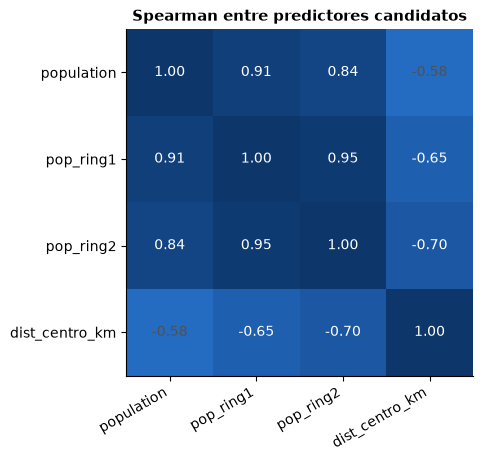

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.abs(), cmap=SECUENCIAL, vmin=0, vmax=1)
ax.set_xticks(range(len(candidatos)), candidatos, rotation=30, ha="right")
ax.set_yticks(range(len(candidatos)), candidatos)
for i in range(len(candidatos)):
    for j in range(len(candidatos)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="white" if abs(corr.iloc[i, j]) > .6 else TINTA)
ax.set_title("Spearman entre predictores candidatos")
guardar_figura(fig, "correlacion_predictores", FASE)

**Decisión (declarada antes de modelar).** `pop_ring1` y `pop_ring2` están casi perfectamente correlacionadas, así
que el modelo usa una sola corona: `pop_ring1`, la más cercana y la más asociada con las consultas en el EDA. Los
predictores quedan fijados en `config.PREDICTORES`.

In [12]:
print("Predictores:", config.PREDICTORES, "| contraste:", config.CONTRASTE)

Predictores: ['dist_centro_km', 'pop_ring1'] | contraste: ['dist_trazado_m', 'gtfs_covered']


## 10. Reserva de prueba por bloques
**Tipo de datos:** espaciales (bloques).

Se sortea, con la semilla, el `FRACCION_PRUEBA` de los bloques de **cada anillo**. La reserva es por bloques porque las
zonas vecinas se parecen (autocorrelación del EDA): una prueba por zonas sueltas dejaría a cada zona de prueba rodeada
de zonas de entrenamiento casi iguales. El sorteo solo usa `block_id` y el anillo; ninguna consulta interviene.

In [13]:
prueba = features.sortear_prueba(bloques, config.FRACCION_PRUEBA, config.SEMILLA)
guardar_tabla(prueba, "test_blocks", FASE)
tabla = tabla.with_columns(pl.col("block_id").is_in(prueba["block_id"].implode()).alias("in_test"))
modelo = tabla.filter(pl.col("in_model"))
conjunto = pl.when(pl.col("in_test")).then(pl.lit("prueba")).otherwise(pl.lit("entrenamiento")).alias("conjunto")
particion = guardar_tabla(features.resumen_por(modelo.with_columns(conjunto), "conjunto"), "particion", FASE)
M.update({"bloques_prueba": prueba.height, "zonas_prueba": int(modelo["in_test"].sum()),
          "pct_consultas_prueba": float(particion.filter(pl.col("conjunto") == "prueba")["pct_consultas"].item())})
particion

conjunto,bloques,zonas,consultas,poblacion,pct_zonas,pct_consultas,consultas_por_1000_hab
str,u32,u32,i64,i64,f64,f64,f64
"""entrenamiento""",41,1029,1738942,908744,74.51,90.37,1913.6
"""prueba""",12,352,185394,316935,25.49,9.63,585.0


⏱ prueba: 2.8 s (acumulado 7 s)


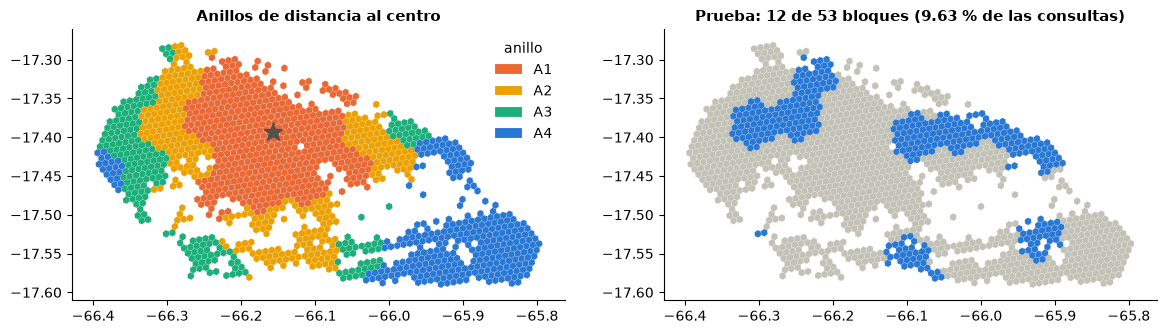

In [14]:
geo = espacial.geo_zonas(modelo.select("h3_cell", "in_test", "distance_ring"))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))
for anillo, color in zip(["A1", "A2", "A3", "A4"], [NARANJA, "#eda100", VERDE, AZUL], strict=True):
    geo[geo["distance_ring"] == anillo].plot(ax=a1, color=color, edgecolor="white", linewidth=0.1, label=anillo)
a1.plot(config.CENTRO_REFERENCIA["lon"], config.CENTRO_REFERENCIA["lat"], "*", color=TINTA, ms=14)
a1.legend(frameon=False, title="anillo")
a1.set_title("Anillos de distancia al centro")
geo[~geo["in_test"]].plot(ax=a2, color=GRIS, edgecolor="white", linewidth=0.1)
geo[geo["in_test"]].plot(ax=a2, color=AZUL, edgecolor="white", linewidth=0.1)
a2.set_title(f"Prueba: {prueba.height} de {bloques.height} bloques ({M['pct_consultas_prueba']} % de las consultas)")
guardar_figura(fig, "anillos_y_prueba", FASE)
tiempo("prueba")

## 11. Descripción de la tabla de modelado
**Tipo de datos:** numéricos (estadísticos) y categóricos (municipio y anillo).

Tres tablas describen las zonas que entran al modelo. Los estadísticos resumen sus variables numéricas. El resumen por
anillo usa la columna `distance_ring` ya asignada, así que comparte los cortes de la partición. El resumen por
municipio mide además cuánto respalda la etiqueta modal: el municipio viene de la exportación de Trufi, no de límites
oficiales. Una zona es de municipio mixto si menos de `UMBRAL_MUNICIPIO_MIXTO` % de sus consultas comparten la etiqueta
modal. Las zonas sin consultas no tienen etiqueta propia y heredan la de sus vecinas más cercanas.

In [15]:
variables = ["query_count", "population", "pop_ring1", "dist_centro_km"]
desc = modelo.select(variables).to_pandas().describe(percentiles=[0.25, 0.5, 0.75]).T
desc = desc.rename(columns={"count": "n", "mean": "media", "25%": "p25", "50%": "mediana", "75%": "p75"})
desc = desc[["n", "media", "std", "min", "p25", "mediana", "p75", "max"]].reset_index(names="variable")
guardar_tabla(desc, "estadisticas_descriptivas", FASE)
guardar_tabla(features.resumen_por(modelo, "distance_ring"), "resumen_anillo", FASE)
desc.round(2)

,variable,n,media,std,min,p25,mediana,p75,max
0,query_count,1381.0,1393.44,8058.41,0.00,0.00,6.00,109.0,152494.00
1,population,1381.0,887.53,1162.59,10.00,97.00,388.00,1183.0,5240.00
2,pop_ring1,1381.0,5221.82,6363.64,3.00,799.00,2398.00,7613.0,28988.00
3,dist_centro_km,1381.0,17.00,9.42,0.51,9.72,15.91,22.1,41.77


In [16]:
pureza = features.pureza_municipio(limpias).join(modelo.select("h3_cell"), on="h3_cell")
pureza = pureza.with_columns((pl.col("pct_modal") < config.UMBRAL_MUNICIPIO_MIXTO).alias("mixta"))
por_municipio = (pureza.group_by("municipality")
                 .agg((pl.col("consultas_modal").sum() / pl.col("consultas_total").sum() * 100).round(2).alias("pct_consultas_modal"),
                      pl.col("mixta").sum().alias("zonas_mixtas"))
                 .join(features.resumen_por(modelo, "municipality").select("municipality", "zonas", "consultas", "poblacion"),
                       on="municipality", how="right").sort("consultas", descending=True))
guardar_tabla(por_municipio.select("municipality", "zonas", "consultas", "poblacion", "pct_consultas_modal", "zonas_mixtas"),
              "resumen_municipio", FASE)
M.update({"pct_consultas_municipio_modal": round(pureza["consultas_modal"].sum() / pureza["consultas_total"].sum() * 100, 2),
          "pct_zonas_municipio_mixto": round(pureza["mixta"].mean() * 100, 2),
          "zonas_municipio_por_vecindad": modelo.height - pureza.height,
          "umbral_municipio_mixto": config.UMBRAL_MUNICIPIO_MIXTO})
por_municipio

pct_consultas_modal,zonas_mixtas,municipality,zonas,consultas,poblacion
f64,u32,str,u32,i64,i64
99.69,13,"""Cochabamba""",318,1662310,622120
99.99,1,"""Sacaba""",259,90113,180427
97.71,12,"""Quillacollo""",137,65275,146291
97.17,5,"""Colcapirhua""",35,53209,47652
92.27,7,"""Tiquipaya""",47,46785,60991
…,…,…,…,…,…
100.0,0,"""Tolata""",37,302,5115
100.0,0,"""Villa Santivañez""",79,300,4163
99.41,1,"""Villa José Quintín Mendoza""",76,170,13386


## 12. Verificaciones

### 12.1 Integridad de la tabla
No se pierde ninguna consulta, no hay zonas repetidas ni valores nulos.

In [17]:
assert tabla["query_count"].sum() == prep["consultas_validas"], "Se perdieron consultas"
assert tabla["h3_cell"].is_unique().all(), "Hay zonas repetidas"
assert tabla.null_count().sum_horizontal().item() == 0, "Hay valores nulos"
print(f"{tabla.height:,} zonas, {tabla['query_count'].sum():,} consultas, sin nulos")

1,628 zonas, 1,924,578 consultas, sin nulos


### 12.2 Rangos válidos
Poblaciones y distancias no negativas, población mínima en el modelo y todas las zonas con municipio.

In [18]:
assert tabla.select("population", "pop_ring1", "pop_ring2", "dist_centro_km", "dist_trazado_m").min().min_horizontal().item() >= 0
assert (modelo["population"] >= config.POP_MIN).all()
assert (tabla["municipality"] != "desconocido").all(), "Hay zonas sin municipio"
print("Rangos correctos")

Rangos correctos


### 12.3 Partición sin solapamiento
Entrenamiento y prueba no comparten bloques ni zonas, y todos los anillos tienen bloques de prueba. Se cuenta cuántas
zonas de prueba tocan zonas de entrenamiento en el borde de su bloque (contagio espacial inevitable en el borde).

In [19]:
entreno, test = modelo.filter(~pl.col("in_test")), modelo.filter(pl.col("in_test"))
assert not set(entreno["block_id"]) & set(test["block_id"]), "Bloques compartidos"
assert not set(entreno["h3_cell"]) & set(test["h3_cell"]), "Zonas compartidas"
assert set(prueba["distance_ring"]) == set(bloques["distance_ring"]), "Algún anillo sin prueba"
en_entreno = set(entreno["h3_cell"])
M["zonas_prueba_borde"] = sum(any(n in en_entreno for n in h3.grid_ring(c, 1)) for c in test["h3_cell"])
print(f"Sin solapamiento. Zonas de prueba en el borde con entrenamiento: {M['zonas_prueba_borde']} de {test.height}")

Sin solapamiento. Zonas de prueba en el borde con entrenamiento: 125 de 352


### 12.4 Sin fuga de información
El objetivo y las variables GTFS no están entre los predictores, y el sorteo de la prueba solo usó bloques y anillos.

In [20]:
assert "query_count" not in config.PREDICTORES, "El objetivo está entre los predictores"
assert not set(config.PREDICTORES) & set(config.CONTRASTE), "Una variable GTFS está entre los predictores"
assert set(prueba.columns) == {"block_id", "block_dist_km", "n_cells", "distance_ring"}, "El sorteo usó otra información"
print("Sin fuga")

Sin fuga


### 12.5 Tablas descriptivas
Las tablas cubren exactamente las zonas y las consultas del modelo, y la pureza es un porcentaje válido (mayor que 0 y hasta 100).

In [21]:
assert por_municipio["zonas"].sum() == M["zonas_modelo"], "El resumen por municipio no cubre las zonas del modelo"
assert por_municipio["consultas"].sum() == M["consultas_modelo"], "El resumen por municipio pierde consultas"
assert pureza["pct_modal"].min() > 0 and pureza["pct_modal"].max() <= 100, "Pureza fuera de rango"
assert (desc["n"] == M["zonas_modelo"]).all(), "Los estadísticos no cubren las zonas del modelo"
print(f"{M['zonas_modelo']:,} zonas; {M['pct_consultas_municipio_modal']} % de las consultas con la etiqueta modal")

1,381 zonas; 99.38 % de las consultas con la etiqueta modal


## 13. Tabla de modelado
Se guarda la tabla con todas las zonas (las que no entran al modelo quedan marcadas con `in_model = False`).

In [22]:
columnas = ["h3_cell", "query_count", "user_count", "query_count_before_gap", "query_count_after_gap", "population",
            "pop_ring1", "pop_ring2", "dist_centro_km", "dist_trazado_m", "gtfs_covered", "municipality",
            "distance_ring", "block_id", "in_model", "in_test", "lat", "lon"]
final = tabla.select(columnas).sort("h3_cell")
final.write_parquet(config.TABLA_MODELADO)
assert pl.read_parquet(config.TABLA_MODELADO).equals(final)
M.update({"zonas": final.height, "columnas": final.width, "semilla": config.SEMILLA,
          "fraccion_prueba": config.FRACCION_PRUEBA, "predictores": config.PREDICTORES})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{config.TABLA_MODELADO.relative_to(config.RAIZ)}: {final.shape}; {len(M)} métricas → {ruta.relative_to(config.RAIZ)}")

⏱ cierre: 2.3 s (acumulado 9 s)
data/processed/tabla_modelado.parquet: (1628, 18); 20 métricas → resultados/03_feature_engineering/metricas.json
